# Module 3 — Bowling Analysis
**Unit IV — Seaborn | IPL 2008–2019**

Charts in this module:
1. Bowler vs Batsman Heatmap ⭐ (showpiece)
2. Economy Rate by Phase (Boxplot)
3. Dismissal Types — Bar chart only
4. Dot Ball % vs Boundary % by Phase (upgraded)
5. Top 10 Bowlers by Wickets (with economy label)
6. Bowler Role Classification — Wickets vs Economy Scatter (quadrants)
7. ⭐ Death Overs Specialists (NEW)
8. ⭐ Powerplay Specialists (NEW)
9. ⭐ Wickets in Winning Matches (NEW — match impact)

## Setup — Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print('Libraries loaded')
from pathlib import Path


Libraries loaded


In [2]:
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'deliveries.csv').exists() and (candidate / 'matches.csv').exists():
            return candidate
    raise FileNotFoundError('Could not find project root containing deliveries.csv and matches.csv')

PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DATA_DIR = PROJECT_ROOT
CLEAN_DATA_DIR = PROJECT_ROOT / 'data' / 'clean'
DERIVED_DATA_DIR = PROJECT_ROOT / 'data' / 'derived'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'

for path in (CLEAN_DATA_DIR, DERIVED_DATA_DIR, FIGURES_DIR):
    path.mkdir(parents=True, exist_ok=True)

print('Project root    ->', PROJECT_ROOT)
print('Clean data dir  ->', CLEAN_DATA_DIR)
print('Derived data dir->', DERIVED_DATA_DIR)
print('Figures dir     ->', FIGURES_DIR)


Project root    -> c:\Users\lakha\OneDrive\Desktop\dv_cp
Clean data dir  -> c:\Users\lakha\OneDrive\Desktop\dv_cp\data\clean
Derived data dir-> c:\Users\lakha\OneDrive\Desktop\dv_cp\data\derived
Figures dir     -> c:\Users\lakha\OneDrive\Desktop\dv_cp\outputs\figures


In [3]:
legal        = pd.read_csv(CLEAN_DATA_DIR / 'legal_deliveries.csv')
bowler_stats = pd.read_csv(DERIVED_DATA_DIR / 'bowler_stats.csv')
deliveries   = pd.read_csv(CLEAN_DATA_DIR / 'deliveries_clean.csv')
player_stats = pd.read_csv(DERIVED_DATA_DIR / 'player_stats.csv')
matches      = pd.read_csv(CLEAN_DATA_DIR / 'matches_clean.csv')

print('legal shape      :', legal.shape)
print('bowler_stats shape:', bowler_stats.shape)
print('deliveries shape :', deliveries.shape)

legal shape      : (173571, 25)
bowler_stats shape: (240, 7)
deliveries shape : (178974, 25)


In [4]:
legal.head(3)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder,season,phase,is_dot_ball,is_boundary
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,NaN,NaN,NaN,2017,Powerplay,1,0
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,NaN,NaN,NaN,2017,Powerplay,1,0
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,4,0,4,NaN,NaN,NaN,2017,Powerplay,0,1


In [5]:
bowler_stats.head(3)

,bowler,runs_conceded,balls,matches,wickets,economy,overs
0,A Ashish Reddy,392,264,20,18,8.91,44.0
1,A Chandila,245,234,12,11,6.28,39.0
2,A Kumble,1063,970,42,45,6.58,161.7


In [6]:
bowler_stats.describe()

,runs_conceded,balls,matches,wickets,economy,overs
count,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000
mean,901.800000,692.470833,35.179167,31.925000,8.032625,115.411250
std,854.308065,682.199089,32.386738,32.934235,0.846546,113.698989
min,151.000000,123.000000,6.000000,3.000000,6.190000,20.500000
25%,301.000000,223.250000,13.000000,9.750000,7.455000,37.175000
50%,540.500000,377.500000,21.500000,18.000000,7.950000,62.900000
75%,1154.750000,895.500000,46.000000,40.000000,8.620000,149.225000
max,4089.000000,3377.000000,157.000000,170.000000,10.950000,562.800000


In [7]:
bowler_stats.isnull().sum()

bowler           0
runs_conceded    0
balls            0
matches          0
wickets          0
economy          0
overs            0
dtype: int64

---
## Chart 8 — ⭐ Bowler vs Batsman Heatmap (SHOWPIECE)
*How many runs did top batsmen score against top bowlers?*

**Broadcaster angle:** This is the matchup matrix — exactly what analysts show
before a big game. Red cells = batsman dominates, light = bowler controls.

In [8]:
# Top 10 batsmen by total runs, top 10 bowlers by wickets
top_bat  = player_stats.nlargest(10, 'total_runs')['batsman'].tolist()
top_bowl = bowler_stats.nlargest(10, 'wickets')['bowler'].tolist()

filtered = legal[legal['batsman'].isin(top_bat) & legal['bowler'].isin(top_bowl)]
pivot = filtered.pivot_table(values='batsman_runs', index='batsman',
                              columns='bowler', aggfunc='sum')
pivot = pivot.fillna(0).round(0)

print('Matchup matrix shape:', pivot.shape)
print(pivot)

Matchup matrix shape: (10, 10)
bowler          A Mishra  B Kumar  DJ Bravo  Harbhajan Singh  PP Chawla  \
batsman                                                                   
AB de Villiers      37.0     48.0      70.0            103.0       53.0   
CH Gayle            67.0    129.0      60.0            103.0      116.0   
DA Warner           43.0      2.0      49.0            112.0       87.0   
G Gambhir           54.0     84.0      32.0             84.0       55.0   
MS Dhoni            51.0     87.0      55.0             47.0       82.0   
RG Sharma           80.0     42.0      83.0             33.0      146.0   
RV Uthappa          84.0     74.0      32.0             77.0       41.0   
S Dhawan            39.0     27.0      69.0            147.0       84.0   
SK Raina           102.0     79.0      55.0            132.0      175.0   
V Kohli            158.0     64.0     130.0             82.0      123.0   

bowler          R Ashwin  RA Jadeja  SL Malinga  SP Narine  UT Yadav

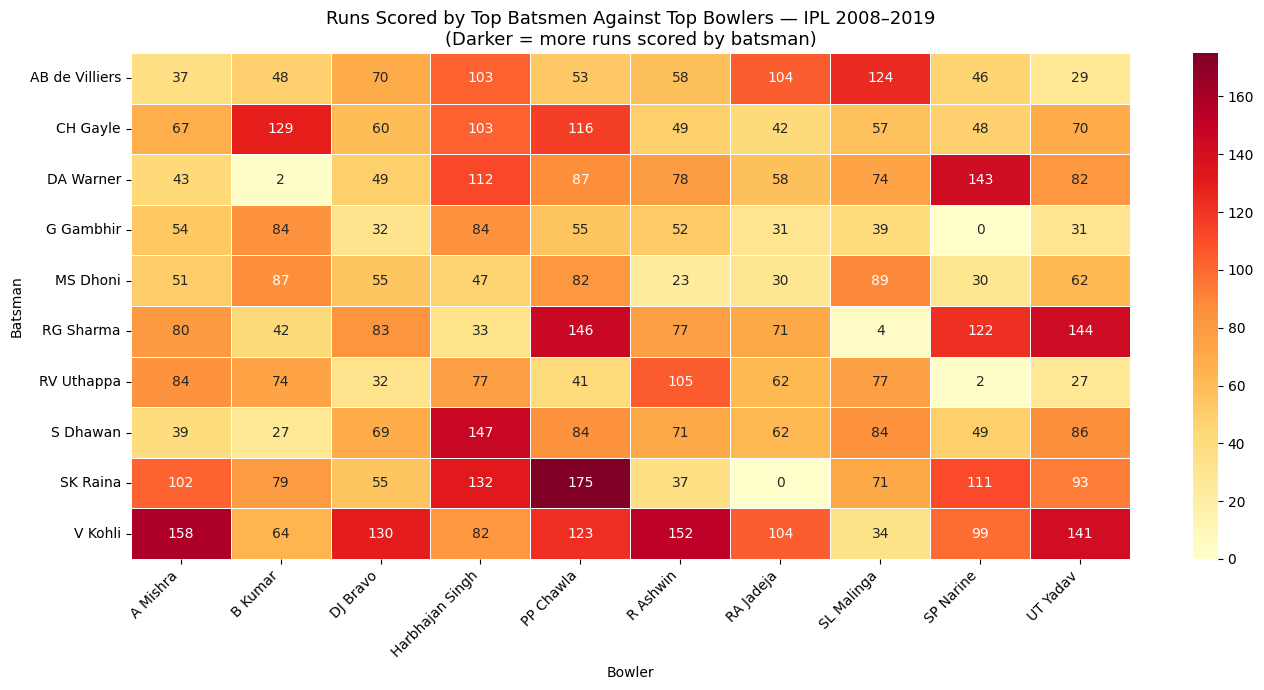


Insight: Red cells show which batsman-bowler matchup heavily favours the batsman.
Light/yellow cells show the bowler has kept that batsman under control.


In [9]:
plt.figure(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Runs Scored by Top Batsmen Against Top Bowlers — IPL 2008–2019\n(Darker = more runs scored by batsman)', fontsize=13)
plt.xlabel('Bowler')
plt.ylabel('Batsman')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'chart8_bowler_batsman_heatmap.png', dpi=150)
plt.show()

print('\nInsight: Red cells show which batsman-bowler matchup heavily favours the batsman.')
print('Light/yellow cells show the bowler has kept that batsman under control.')

---
## Chart 9 — Economy Rate by Phase (Boxplot)
*Which phase is the hardest to bowl in?*

The boxplot shows not just the average but the spread — some bowlers concede
very differently in the same phase. Death overs have the highest median AND
the widest spread, meaning results vary most in the final overs.

In [10]:
# Economy per bowler per phase — using legal deliveries
eco = legal.groupby(['bowler', 'phase']).agg(
    runs  = ('total_runs', 'sum'),
    balls = ('ball', 'count')
).reset_index()
eco['economy'] = (eco['runs'] / eco['balls'] * 6).round(2)

# Minimum 30 legal balls per phase to avoid small-sample noise
eco = eco[eco['balls'] >= 30]

print('Economy stats by phase:')
print(eco.groupby('phase')['economy'].describe().round(2))

Economy stats by phase:
           count  mean   std   min   25%   50%    75%    max
phase                                                       
Death      199.0  9.68  1.46  6.20  8.76  9.49  10.52  14.82
Middle     284.0  7.67  1.14  3.00  7.05  7.68   8.28  11.57
Powerplay  227.0  7.79  1.40  3.92  6.82  7.58   8.76  11.40


C:\Users\lakha\AppData\Local\Temp\ipykernel_17948\3504856397.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=eco, x='phase', y='economy',


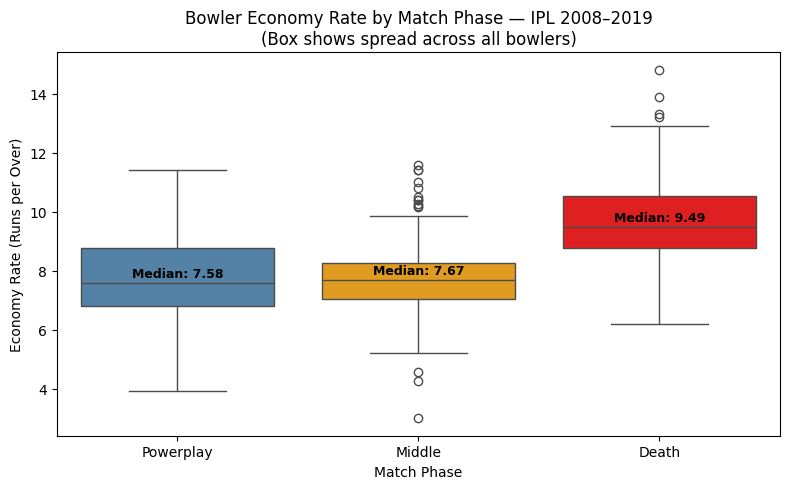


Insight: Death overs have highest median economy AND widest spread.
A bowler who keeps economy low in death overs is genuinely elite.


In [11]:
phase_order = ['Powerplay', 'Middle', 'Death']
phase_medians = eco.groupby('phase')['economy'].median().reindex(phase_order)

plt.figure(figsize=(8, 5))
ax = sns.boxplot(data=eco, x='phase', y='economy',
                 order=phase_order,
                 palette={'Powerplay': 'steelblue', 'Middle': 'orange', 'Death': 'red'})

# Annotate medians
for i, phase in enumerate(phase_order):
    med = phase_medians[phase]
    ax.text(i, med + 0.2, f'Median: {med:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.title('Bowler Economy Rate by Match Phase — IPL 2008–2019\n(Box shows spread across all bowlers)', fontsize=12)
plt.xlabel('Match Phase')
plt.ylabel('Economy Rate (Runs per Over)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'chart9_economy_boxplot.png', dpi=150)
plt.show()

print('\nInsight: Death overs have highest median economy AND widest spread.')
print('A bowler who keeps economy low in death overs is genuinely elite.')

---
## Chart 10 — Dismissal Types
*How do batsmen get out in IPL? Which method is most common?*

**Note:** Pie chart removed — bar chart is clearer for comparing 9 categories.
% labels added so the chart tells the full story without needing a table.

In [12]:
dismissals = deliveries['dismissal_kind'].dropna().value_counts()
dismissal_pct = (dismissals / dismissals.sum() * 100).round(1)

print('Dismissal type breakdown:')
for kind, count in dismissals.items():
    print(f'  {kind:<25} {count:>5}  ({dismissal_pct[kind]}%)')

Dismissal type breakdown:
  caught                     5342  (60.6%)
  bowled                     1578  (17.9%)
  run out                     848  (9.6%)
  lbw                         539  (6.1%)
  stumped                     278  (3.2%)
  caught and bowled           211  (2.4%)
  retired hurt                 12  (0.1%)
  hit wicket                   10  (0.1%)
  obstructing the field         2  (0.0%)


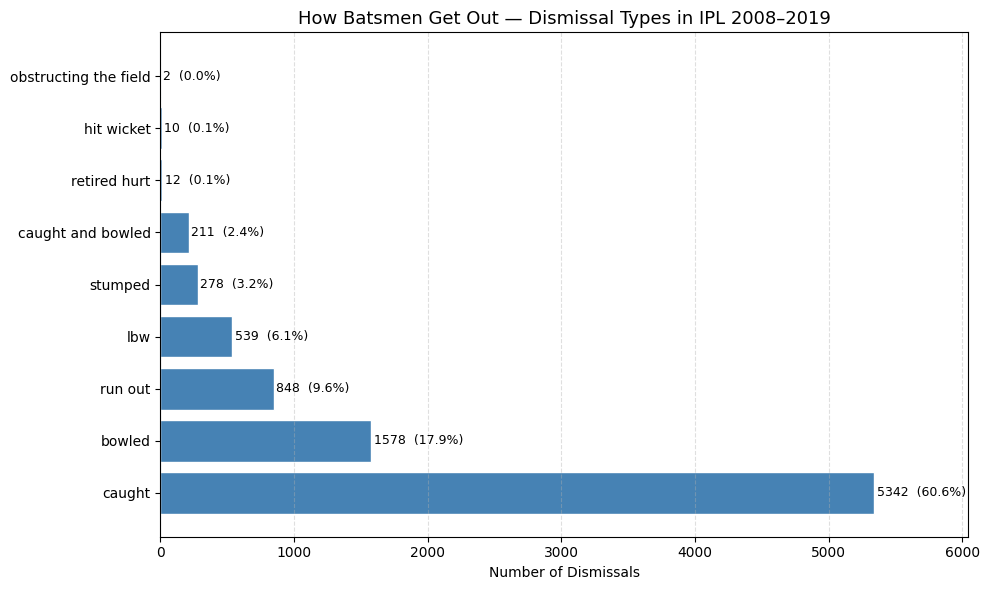


Insight: Caught accounts for over 60% of all dismissals.
Batsmen in T20 take aerial risks — the data confirms it.


In [13]:
plt.figure(figsize=(10, 6))
bars = plt.barh(dismissals.index, dismissals.values,
                color='steelblue', edgecolor='white')

# Add count + % label at end of each bar
for bar, (kind, count) in zip(bars, dismissals.items()):
    pct = dismissal_pct[kind]
    plt.text(bar.get_width() + 20,
             bar.get_y() + bar.get_height()/2,
             f'{count}  ({pct}%)', va='center', fontsize=9)

plt.title('How Batsmen Get Out — Dismissal Types in IPL 2008–2019', fontsize=13)
plt.xlabel('Number of Dismissals')
plt.xlim(0, dismissals.max() + 700)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'chart10_dismissals.png', dpi=150)
plt.show()

print('\nInsight: Caught accounts for over 60% of all dismissals.')
print('Batsmen in T20 take aerial risks — the data confirms it.')

---
## Chart 11 — Dot Ball % vs Boundary % by Phase
*Bowling pressure vs damage risk — how the balance shifts across phases*

**Why show both:** Dot ball % shows bowling pressure. Boundary % shows hitting risk.
Together they tell the complete story of each phase.

In [14]:
legal['is_dot']      = (legal['total_runs'] == 0)
legal['is_boundary'] = legal['batsman_runs'].isin([4, 6])

phase_order = ['Powerplay', 'Middle', 'Death']

dot_pct      = (legal.groupby('phase')['is_dot'].mean() * 100).reindex(phase_order).round(1)
boundary_pct = (legal.groupby('phase')['is_boundary'].mean() * 100).reindex(phase_order).round(1)

print('Phase     | Dot Ball %  | Boundary %')
for phase in phase_order:
    print(f'{phase:<10}|  {dot_pct[phase]:>7}%   |  {boundary_pct[phase]:>7}%')

Phase     | Dot Ball %  | Boundary %
Powerplay |     47.6%   |     19.0%
Middle    |     32.7%   |     13.2%
Death     |     27.9%   |     19.5%


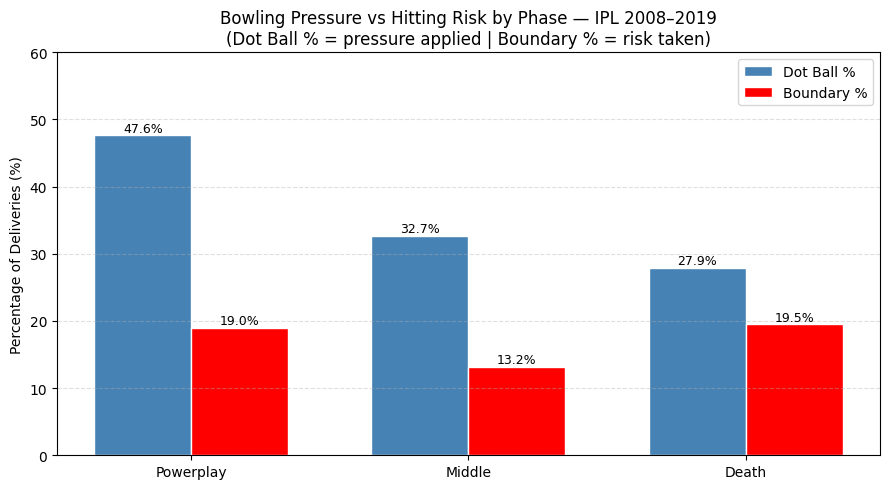


Insight: Powerplay has the highest dot ball % — batsmen play cautiously early.
Death overs: dot % drops but boundary % rises sharply — pure attacking phase.


In [15]:
x = range(len(phase_order))
width = 0.35

plt.figure(figsize=(9, 5))
bars1 = plt.bar([i - width/2 for i in x], dot_pct.values,
                width, label='Dot Ball %', color='steelblue', edgecolor='white')
bars2 = plt.bar([i + width/2 for i in x], boundary_pct.values,
                width, label='Boundary %', color='red', edgecolor='white')

# Value labels
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=9)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.xticks(list(x), phase_order)
plt.title('Bowling Pressure vs Hitting Risk by Phase — IPL 2008–2019\n(Dot Ball % = pressure applied | Boundary % = risk taken)', fontsize=12)
plt.ylabel('Percentage of Deliveries (%)')
plt.legend(fontsize=10)
plt.ylim(0, 60)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'chart11_dot_boundary_phase.png', dpi=150)
plt.show()

print('\nInsight: Powerplay has the highest dot ball % — batsmen play cautiously early.')
print('Death overs: dot % drops but boundary % rises sharply — pure attacking phase.')

---
## Chart 12 — Top 10 Bowlers by Wickets
*Who are the biggest wicket-takers across 12 seasons?*

Economy shown alongside wickets — because wickets alone don't tell the full story.
A bowler with 150 wickets at economy 8.5 is less valuable than one at 7.0.

In [16]:
top_bowl = bowler_stats.nlargest(10, 'wickets').sort_values('wickets')
print(top_bowl[['bowler', 'wickets', 'economy', 'overs']].to_string())

              bowler  wickets  economy  overs
171        RA Jadeja      107     7.57  416.2
222         UT Yadav      119     8.38  416.3
161         R Ashwin      122     6.68  487.8
208        SP Narine      122     6.69  426.5
30           B Kumar      133     7.18  436.7
75   Harbhajan Singh      146     7.01  562.8
55          DJ Bravo      147     8.28  432.0
156        PP Chawla      149     7.85  521.0
3           A Mishra      156     7.28  520.3
204       SL Malinga      170     7.05  474.2


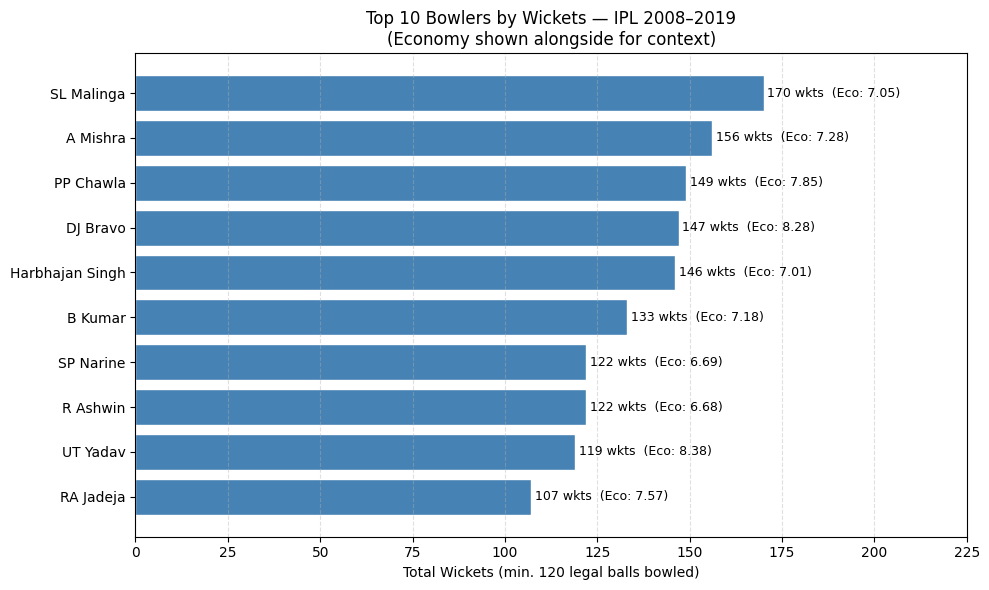

In [17]:
plt.figure(figsize=(10, 6))
bars = plt.barh(top_bowl['bowler'], top_bowl['wickets'], color='steelblue', edgecolor='white')

# Label with wickets + economy
for bar, (_, row) in zip(bars, top_bowl.iterrows()):
    plt.text(bar.get_width() + 1,
             bar.get_y() + bar.get_height()/2,
             f"{int(row['wickets'])} wkts  (Eco: {row['economy']})",
             va='center', fontsize=9)

plt.title('Top 10 Bowlers by Wickets — IPL 2008–2019\n(Economy shown alongside for context)', fontsize=12)
plt.xlabel('Total Wickets (min. 120 legal balls bowled)')
plt.xlim(0, top_bowl['wickets'].max() + 55)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'chart12_top_bowlers.png', dpi=150)
plt.show()

---
## Chart 13 — Bowler Role Classification: Wickets vs Economy
*Which bowlers are elite? Which are defensive? Which are aggressive but expensive?*

**Quadrant logic (no ML — pure threshold):**
- Elite: Low economy + high wickets
- Aggressive: High wickets but expensive
- Defensive: Low economy but fewer wickets
- Weak: High economy + low wickets

In [18]:
top80 = bowler_stats.nlargest(80, 'wickets').copy()

eco_median = top80['economy'].median()
wkt_median = top80['wickets'].median()

print(f'Wickets median : {wkt_median}')
print(f'Economy median : {eco_median}')

# Assign quadrant role
roles = []
for i in range(len(top80)):
    low_eco  = top80.iloc[i]['economy']  <= eco_median
    high_wkt = top80.iloc[i]['wickets']  >= wkt_median
    if low_eco and high_wkt:
        roles.append('Elite')
    elif not low_eco and high_wkt:
        roles.append('Aggressive')
    elif low_eco and not high_wkt:
        roles.append('Defensive')
    else:
        roles.append('Average')

top80['role'] = roles
print('\nRole distribution:')
print(top80['role'].value_counts())

Wickets median : 60.0
Economy median : 7.805

Role distribution:
role
Elite         23
Average       23
Aggressive    17
Defensive     17
Name: count, dtype: int64


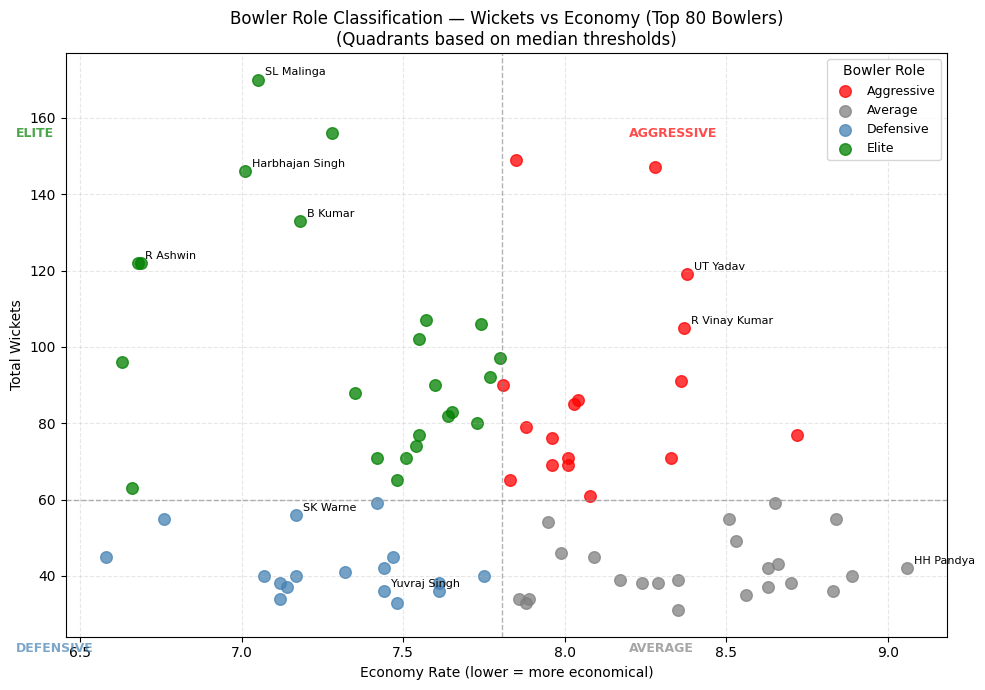

In [19]:
color_map = {'Elite': 'green', 'Aggressive': 'red', 'Defensive': 'steelblue', 'Average': 'gray'}

plt.figure(figsize=(10, 7))

for role, group in top80.groupby('role'):
    plt.scatter(group['economy'], group['wickets'],
                c=color_map[role], label=role, alpha=0.75, s=70)

# Label top elite players
notable = ['SL Malinga', 'Yuvraj Singh', 'R Ashwin', 'Harbhajan Singh', 'B Kumar', 'SK Warne', 'UT Yadav', 'R Vinay Kumar', 'HH Pandya']
for _, row in top80[top80['bowler'].isin(notable)].iterrows():
    plt.annotate(row['bowler'], (row['economy'], row['wickets']),
                 textcoords='offset points', xytext=(5, 3), fontsize=8)

# Draw quadrant lines
plt.axvline(eco_median, color='gray', linestyle='--', linewidth=1, alpha=0.6)
plt.axhline(wkt_median, color='gray', linestyle='--', linewidth=1, alpha=0.6)

# Quadrant labels
plt.text(6.3, 155, 'ELITE', fontsize=9, color='green', fontweight='bold', alpha=0.7)
plt.text(8.2, 155, 'AGGRESSIVE', fontsize=9, color='red', fontweight='bold', alpha=0.7)
plt.text(6.3, 20,  'DEFENSIVE', fontsize=9, color='steelblue', fontweight='bold', alpha=0.7)
plt.text(8.2, 20,  'AVERAGE', fontsize=9, color='gray', fontweight='bold', alpha=0.7)

plt.title('Bowler Role Classification — Wickets vs Economy (Top 80 Bowlers)\n(Quadrants based on median thresholds)', fontsize=12)
plt.xlabel('Economy Rate (lower = more economical)')
plt.ylabel('Total Wickets')
plt.legend(title='Bowler Role', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'chart13_bowler_scatter.png', dpi=150)
plt.show()

---
## Chart 14 — ⭐ Death Overs Specialists (NEW)
*Who are the best bowlers in overs 16–20? The hardest phase to bowl.*

**Broadcaster angle:** Death bowling is the most pressure-filled role in T20.
This chart finds bowlers who can control runs AND take wickets when it matters most.

Filter: Minimum 10 death overs bowled (60 legal balls) for meaningful comparison.

In [20]:
# Bowler wicket kinds — same as Module 1 definition
bowler_wicket_kinds = ['bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']

# Filter death overs only
death = legal[legal['phase'] == 'Death'].copy()

# Runs conceded and balls bowled in death overs
death_base = death.groupby('bowler').agg(
    runs  = ('total_runs', 'sum'),
    balls = ('ball', 'count')
).reset_index()

# Wickets taken in death overs only
death_wkts = death[death['dismissal_kind'].isin(bowler_wicket_kinds)]
death_wkts = death_wkts.groupby('bowler').size().reset_index(name='wickets')

death_stats = death_base.merge(death_wkts, on='bowler', how='left')
death_stats['wickets'] = death_stats['wickets'].fillna(0).astype(int)
death_stats['economy'] = (death_stats['runs'] / death_stats['balls'] * 6).round(2)
death_stats['overs']   = (death_stats['balls'] / 6).round(1)

# Minimum 30 death overs bowled
death_stats = death_stats[death_stats['balls'] >= 180].reset_index(drop=True)

# Top 10 by economy (most economical in death)
top_death = death_stats.nsmallest(10, 'economy').sort_values('economy', ascending=False)

print('Top 10 Death Overs Specialists (by economy):')
print(top_death[['bowler', 'economy', 'wickets', 'overs']].to_string())

Top 10 Death Overs Specialists (by economy):
               bowler  economy  wickets  overs
42  Mustafizur Rahman     8.05       13   38.5
67         WD Parnell     8.01       14   34.8
34     M Muralitharan     7.99       22   45.8
16           DW Steyn     7.93       49  102.5
19    Harbhajan Singh     7.92       25   44.8
57         SL Malinga     7.88      108  187.5
35           MA Starc     7.63       17   33.8
59          SP Narine     7.52       57  132.5
47           R Ashwin     7.46       28   73.5
11       DE Bollinger     7.40       23   39.3


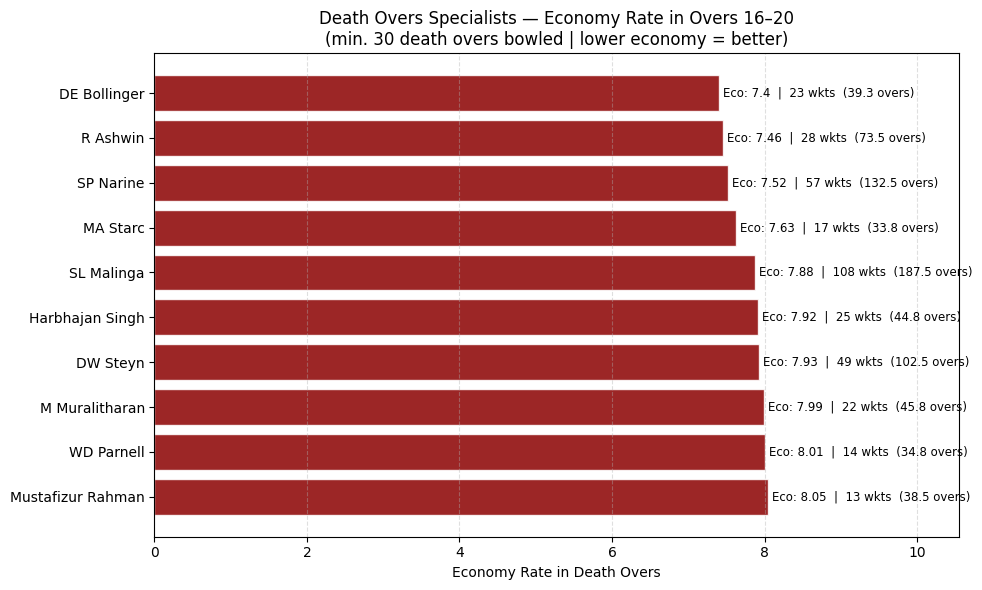


Insight: SP Narine is remarkably economical in death overs despite being a spinner.
Most death specialists are pace bowlers — their ability to bowl yorkers is key.


In [21]:
plt.figure(figsize=(10, 6))
bars = plt.barh(top_death['bowler'], top_death['economy'],
                color='darkred', edgecolor='white', alpha=0.85)

# Add economy + wickets as label
for bar, (_, row) in zip(bars, top_death.iterrows()):
    plt.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height()/2,
             f"Eco: {row['economy']}  |  {int(row['wickets'])} wkts  ({row['overs']} overs)",
             va='center', fontsize=8.5)

plt.title('Death Overs Specialists — Economy Rate in Overs 16–20\n(min. 30 death overs bowled | lower economy = better)', fontsize=12)
plt.xlabel('Economy Rate in Death Overs')
plt.xlim(0, top_death['economy'].max() + 2.5)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'chart14_death_specialists.png', dpi=150)
plt.show()

print('\nInsight: SP Narine is remarkably economical in death overs despite being a spinner.')
print('Most death specialists are pace bowlers — their ability to bowl yorkers is key.')

---
## Chart 15 — ⭐ Powerplay Specialists (NEW)
*Who are the best bowlers in overs 1–6? New ball + fielding restrictions phase.*

**Why this matters:** Powerplay bowling is a different skill — swing, bounce,
taking early wickets to restrict innings. Compared to death bowling, economy
is easier here but early wickets are more valuable.

Filter: Minimum 10 powerplay overs bowled.

In [22]:
# Filter powerplay overs only
pp = legal[legal['phase'] == 'Powerplay'].copy()

pp_base = pp.groupby('bowler').agg(
    runs  = ('total_runs', 'sum'),
    balls = ('ball', 'count')
).reset_index()

pp_wkts = pp[pp['dismissal_kind'].isin(bowler_wicket_kinds)]
pp_wkts = pp_wkts.groupby('bowler').size().reset_index(name='wickets')

pp_stats = pp_base.merge(pp_wkts, on='bowler', how='left')
pp_stats['wickets'] = pp_stats['wickets'].fillna(0).astype(int)
pp_stats['economy'] = (pp_stats['runs'] / pp_stats['balls'] * 6).round(2)
pp_stats['overs']   = (pp_stats['balls'] / 6).round(1)

# Minimum 30 powerplay overs bowled
pp_stats = pp_stats[pp_stats['balls'] >= 180].reset_index(drop=True)

# Top 10 by economy in powerplay
top_pp = pp_stats.nsmallest(10, 'economy').sort_values('economy', ascending=False)

print('Top 10 Powerplay Specialists (by economy):')
print(top_pp[['bowler', 'economy', 'wickets', 'overs']].to_string())

Top 10 Powerplay Specialists (by economy):
           bowler  economy  wickets  overs
53       R Ashwin     6.31       33  136.0
25  Iqbal Abdulla     6.24       14   46.0
61     SL Malinga     6.21       37  186.2
11  BW Hilfenhaus     6.20       12   40.2
62     SM Pollock     6.15        8   34.0
16      DP Nannes     6.02       15   57.2
18       DW Steyn     6.02       34  183.7
8         B Kumar     5.93       46  231.2
64      SP Narine     5.91       24  115.0
19     GD McGrath     5.78        8   37.0


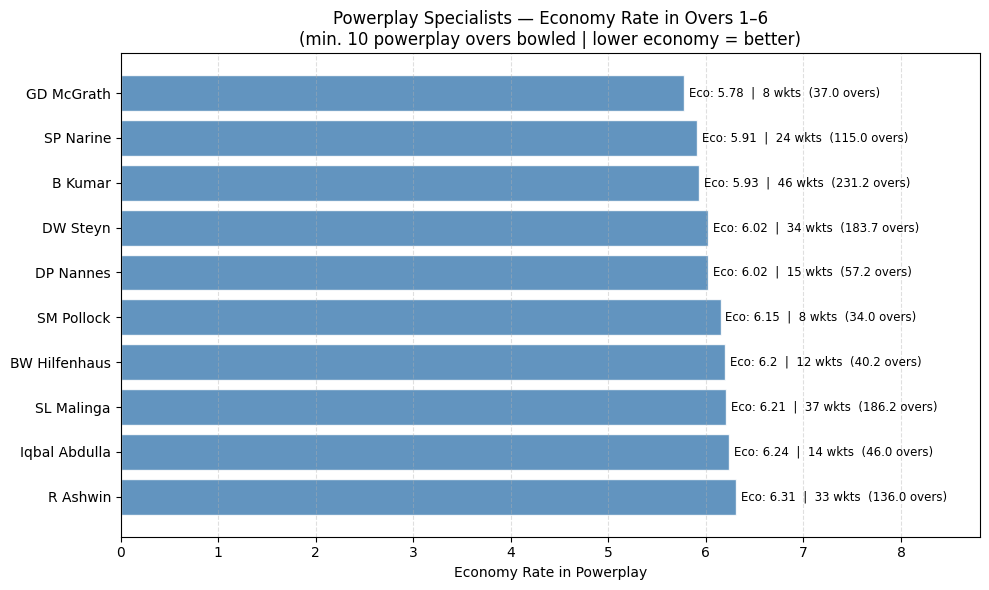


Insight: Powerplay economy is naturally lower than death economy.
Early wickets + run restriction = ideal powerplay bowling template.


In [23]:
plt.figure(figsize=(10, 6))
bars = plt.barh(top_pp['bowler'], top_pp['economy'],
                color='steelblue', edgecolor='white', alpha=0.85)

for bar, (_, row) in zip(bars, top_pp.iterrows()):
    plt.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height()/2,
             f"Eco: {row['economy']}  |  {int(row['wickets'])} wkts  ({row['overs']} overs)",
             va='center', fontsize=8.5)

plt.title('Powerplay Specialists — Economy Rate in Overs 1–6\n(min. 10 powerplay overs bowled | lower economy = better)', fontsize=12)
plt.xlabel('Economy Rate in Powerplay')
plt.xlim(0, top_pp['economy'].max() + 2.5)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'chart15_powerplay_specialists.png', dpi=150)
plt.show()

print('\nInsight: Powerplay economy is naturally lower than death economy.')
print('Early wickets + run restriction = ideal powerplay bowling template.')

---
## Chart 16 — ⭐ Wickets in Winning Matches (Match Impact)
*Who takes wickets when their team is winning — the match-impact bowlers?*

**Why this matters:** A bowler may have 150 wickets, but if most came in
losing matches, they didn't change outcomes. This chart finds bowlers
whose wickets consistently come in wins — the real impact players.

In [24]:
# Merge legal deliveries with match winner
merged = legal.merge(matches[['id', 'winner']], left_on='match_id', right_on='id')

# Did the bowling team win?
merged['bowl_team_won'] = (merged['bowling_team'] == merged['winner']).astype(int)

# Only wicket-taking deliveries (bowler-credited)
wkt_rows = merged[merged['dismissal_kind'].isin(bowler_wicket_kinds)]

# Wickets in winning vs total wickets
win_wkts   = wkt_rows[wkt_rows['bowl_team_won'] == 1].groupby('bowler').size().reset_index(name='wickets_in_wins')
total_wkts = wkt_rows.groupby('bowler').size().reset_index(name='total_wickets')

impact = win_wkts.merge(total_wkts, on='bowler')
impact['win_wkt_pct'] = (impact['wickets_in_wins'] / impact['total_wickets'] * 100).round(1)

# Minimum 50 total wickets for meaningful comparison
impact = impact[impact['total_wickets'] >= 50].reset_index(drop=True)

# Top 12 by wickets in wins
top_impact = impact.nlargest(12, 'wickets_in_wins').sort_values('wickets_in_wins')

print('Bowlers with most wickets in winning matches:')
print(top_impact[['bowler', 'wickets_in_wins', 'total_wickets', 'win_wkt_pct']].to_string())

Bowlers with most wickets in winning matches:
             bowler  wickets_in_wins  total_wickets  win_wkt_pct
33    R Vinay Kumar               67            105         63.8
27        MM Sharma               69             91         75.8
5           B Kumar               72            133         54.1
34        RA Jadeja               75            107         70.1
40        SP Narine               75            122         61.5
44         UT Yadav               76            119         63.9
31         R Ashwin               81            122         66.4
29        PP Chawla               91            149         61.1
0          A Mishra               94            156         60.3
7          DJ Bravo               96            147         65.3
10  Harbhajan Singh              100            146         68.5
39       SL Malinga              124            170         72.9


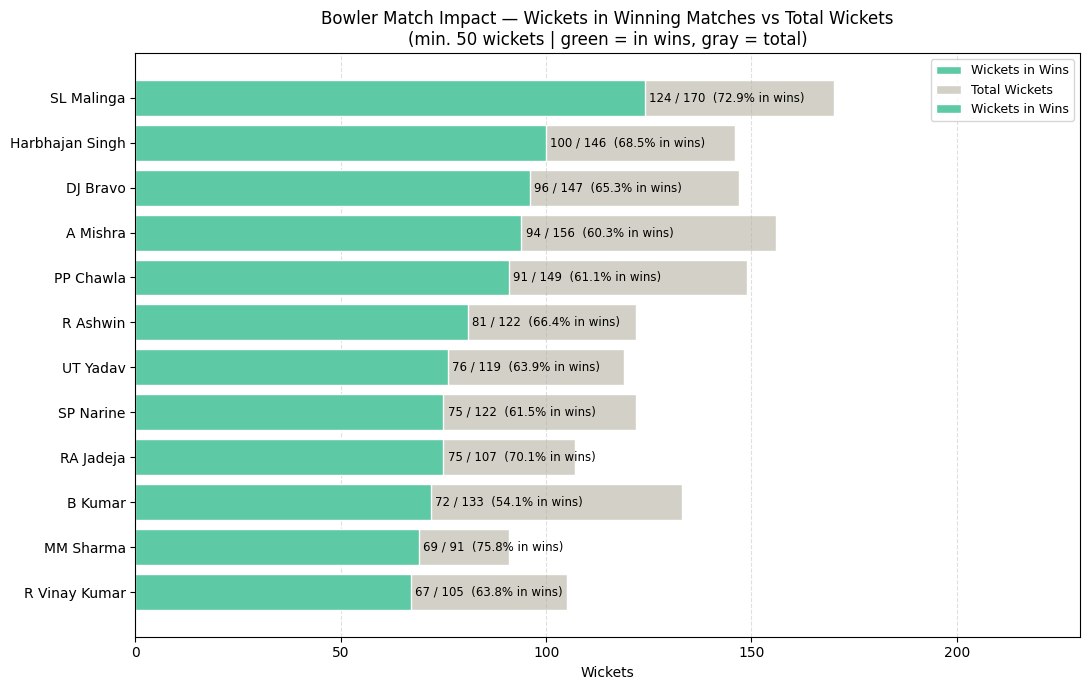


Insight: Malinga has 73% of his wickets in winning matches — true match-winner.
Bowlers with high win% are game-changers, not just volume wicket-takers.


In [25]:
plt.figure(figsize=(11, 7))

bars = plt.barh(top_impact['bowler'], top_impact['wickets_in_wins'],
                color='#5DCAA5', edgecolor='white', label='Wickets in Wins')

# Also show total wickets as a lighter bar behind
plt.barh(top_impact['bowler'], top_impact['total_wickets'],
         color='#D3D1C7', edgecolor='white', label='Total Wickets', zorder=1)
plt.barh(top_impact['bowler'], top_impact['wickets_in_wins'],
         color='#5DCAA5', edgecolor='white', label='Wickets in Wins', zorder=2)

# Label with win %
for bar, (_, row) in zip(bars, top_impact.iterrows()):
    plt.text(bar.get_width() + 1,
             bar.get_y() + bar.get_height()/2,
             f"{int(row['wickets_in_wins'])} / {int(row['total_wickets'])}  ({row['win_wkt_pct']}% in wins)",
             va='center', fontsize=8.5)

plt.title('Bowler Match Impact — Wickets in Winning Matches vs Total Wickets\n(min. 50 wickets | green = in wins, gray = total)', fontsize=12)
plt.xlabel('Wickets')
plt.xlim(0, top_impact['total_wickets'].max() + 60)
plt.legend(fontsize=9)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'chart16_wickets_winning.png', dpi=150)
plt.show()

print('\nInsight: Malinga has 73% of his wickets in winning matches — true match-winner.')
print('Bowlers with high win% are game-changers, not just volume wicket-takers.')